# Question 1 : Impact Relatif des Facteurs sur le Bonheur

**Objectif :** Visualiser l'influence spécifique de l'économie, du soutien social, de la santé, de la liberté, de la générosité et de la corruption sur le score de bonheur (`Life Ladder`).

In [6]:
# Importations essentielles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Style graphique (optionnel)
sns.set_theme(style="whitegrid")

print("Bibliothèques importées.")

Bibliothèques importées.


In [7]:
# --- Chargement initial unique des données ---

# Chemin du fichier
file_path = 'CSVs/world_happiness_report_2024.csv' 
# Si vous avez téléversé le dossier WorldHappinessReport/, le chemin pourrait être :
# file_path = 'WorldHappinessReport/CSVs/world_happiness_report_2024.csv'

# Charger TOUTES les colonnes utiles pour les questions (ou toutes par simplicité)
try:
    df_whr_full = pd.read_csv(file_path)
    print(f"Données complètes chargées depuis {file_path}. Dimensions: {df_whr_full.shape}")
    
    # Afficher un aperçu et les infos (optionnel)
    # display(df_whr_full.head())
    # print("\nInfos sur le DataFrame complet:")
    # df_whr_full.info()

except FileNotFoundError:
    print(f"ERREUR : Le fichier {file_path} n'a pas été trouvé. Vérifiez le chemin.")
    # Arrêter potentiellement l'exécution si le fichier n'est pas trouvé
    df_whr_full = None 
except Exception as e:
    print(f"Une erreur est survenue lors du chargement: {e}")
    df_whr_full = None

Données complètes chargées depuis CSVs/world_happiness_report_2024.csv. Dimensions: (2363, 11)


Préparation pour Q1: 2103 observations utilisées après nettoyage des NaN.
Formule Q1 utilisée : Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Social support") + Q("Healthy life expectancy at birth") + Q("Freedom to make life choices") + Q("Generosity") + Q("Perceptions of corruption")
Modèle de régression Q1 ajusté.
Génération du graphique des coefficients Q1...


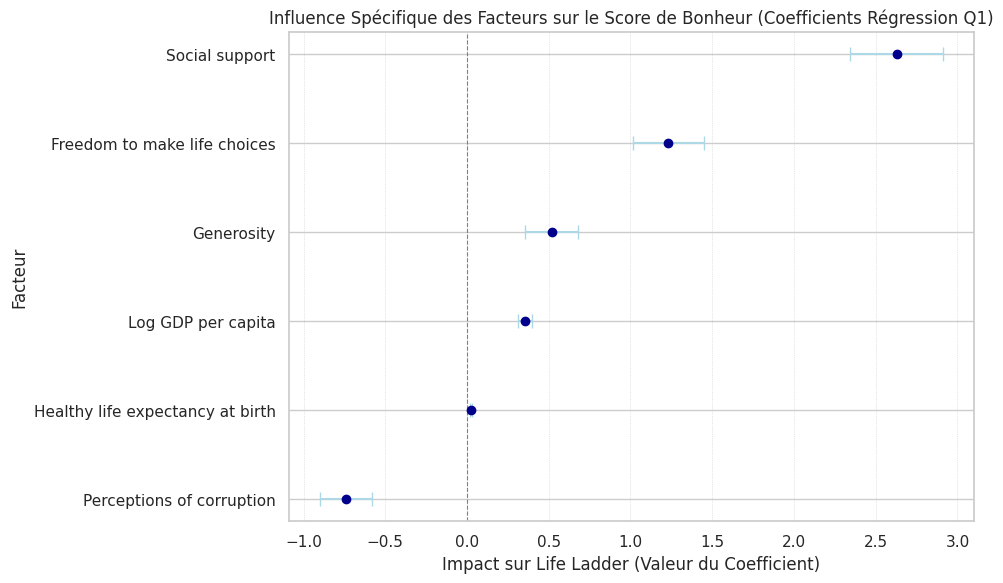

In [8]:
# --- Analyse et Graphique Principal Q1 (Coefficient Plot) ---

if df_whr_full is not None: # Vérifie si le chargement a réussi
    
    # Colonnes nécessaires SPÉCIFIQUEMENT pour la régression Q1
    colonnes_regression_q1 = [
        'Life Ladder',
        'Log GDP per capita',
        'Social support',
        'Healthy life expectancy at birth',
        'Freedom to make life choices',
        'Generosity',
        'Perceptions of corruption'
    ]

    # Préparation des données A LA VOLEE pour Q1: sélectionner + nettoyer NaN
    df_q1_analysis_data = df_whr_full[colonnes_regression_q1].dropna()
    print(f"Préparation pour Q1: {len(df_q1_analysis_data)} observations utilisées après nettoyage des NaN.")

    # Définir la formule de régression avec Q()
    predictor_cols_q = [f'Q("{col}")' for col in colonnes_regression_q1 if col != 'Life Ladder']
    formula_q1 = f'Q("Life Ladder") ~ {" + ".join(predictor_cols_q)}'
    print(f"Formule Q1 utilisée : {formula_q1}")

    try:
        # Ajuster le modèle OLS sur les données nettoyées pour Q1
        model_q1 = smf.ols(formula=formula_q1, data=df_q1_analysis_data)
        results_q1 = model_q1.fit()
        print("Modèle de régression Q1 ajusté.")

        # --- Création du Graphique des Coefficients (identique à avant) ---
        print("Génération du graphique des coefficients Q1...")
        coeffs = results_q1.params.drop('Intercept')
        conf_int = results_q1.conf_int().drop('Intercept')
        coeffs.index = [name.replace('Q("', '').replace('")', '') for name in coeffs.index]
        conf_int.index = [name.replace('Q("', '').replace('")', '') for name in conf_int.index]
        coeffs_sorted = coeffs.sort_values()
        conf_int_sorted = conf_int.loc[coeffs_sorted.index]
        
        plt.figure(figsize=(10, 6))
        err = (conf_int_sorted[1] - conf_int_sorted[0]) / 2
        plt.errorbar(coeffs_sorted, coeffs_sorted.index, xerr=err, fmt='o', color='darkblue', ecolor='lightblue', capsize=5, label='Coefficient (IC 95%)')
        plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
        plt.title('Influence Spécifique des Facteurs sur le Score de Bonheur (Coefficients Régression Q1)')
        plt.xlabel('Impact sur Life Ladder (Valeur du Coefficient)')
        plt.ylabel('Facteur')
        plt.grid(axis='x', linestyle=':', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue lors de l'analyse ou la visualisation Q1 : {e}")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q1 annulée.")

**Conclusion (Basée sur le graphique des coefficients)**

Le graphique ci-dessus illustre l'influence spécifique estimée de chaque facteur sur le score de bonheur (`Life Ladder`), une fois l'effet des autres facteurs pris en compte :

* **Signification :** Tous les facteurs sont statistiquement significatifs, car leurs intervalles de confiance (barres horizontales claires) ne coupent pas la ligne verticale à zéro.
* **Impacts Positifs (points à droite de zéro) :**
    * Le `Social support` (soutien social) se distingue nettement avec le coefficient positif le plus élevé (le point bleu le plus à droite, vers +2.6), indiquant l'impact positif le plus fort.
    * La `Freedom to make life choices` (liberté de choix) montre également un impact positif très important (vers +1.2).
    * Viennent ensuite, avec des impacts positifs notables mais moindres, la `Generosity` (générosité, vers +0.5) et le `Log GDP per capita` (PIB logarithmique, vers +0.35).
    * La `Healthy life expectancy at birth` (espérance de vie en bonne santé) a l'impact positif le plus faible parmi les facteurs significatifs (proche de zéro, vers +0.03).
* **Impact Négatif (point à gauche de zéro) :**
    * La `Perceptions of corruption` (perception de la corruption) est le seul facteur ayant un impact négatif significatif (vers -0.75). Une perception élevée de la corruption est donc associée à un score de bonheur plus bas.

En résumé, ce graphique met en évidence l'importance prépondérante du soutien social et de la liberté perçue pour expliquer le bonheur. L'économie, la générosité et la santé y contribuent aussi positivement mais à des degrés divers, tandis que la perception de la corruption agit clairement comme un frein au bien-être tel que mesuré par le `Life Ladder`.

# Question 2 : Pays "Hors Normes" Économiques

**Objectif :** Identifier les pays dont le score de bonheur (`Life Ladder`) est supérieur à ce que leur niveau de PIB par habitant (`Log GDP per capita`) laisserait présager.

In [9]:
# --- Préparation et Analyse des Résidus Q2 ---

if df_whr_full is not None: # Vérifie si le chargement initial a réussi
    
    # 1. Sélectionner les données les plus récentes par pays depuis df_whr_full
    df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    print(f"Préparation pour Q2: Données les plus récentes sélectionnées pour {len(df_latest)} pays.")

    # 2. Nettoyer les NaN SPÉCIFIQUEMENT pour les colonnes de Q2 (Life Ladder, Log GDP)
    colonnes_q2 = ['Life Ladder', 'Log GDP per capita', 'Country', 'year'] # Inclure Country/Year pour les labels
    df_q2_analysis_data = df_latest[colonnes_q2].dropna(subset=['Life Ladder', 'Log GDP per capita'])
    print(f"Préparation pour Q2: {len(df_q2_analysis_data)} observations utilisées après nettoyage des NaN pour LL et GDP.")

    # 3. Régression simple : Bonheur ~ PIB sur les données nettoyées de Q2
    formula_q2 = 'Q("Life Ladder") ~ Q("Log GDP per capita")'
    model_q2 = smf.ols(formula=formula_q2, data=df_q2_analysis_data)
    results_q2 = model_q2.fit()
    print("Régression simple Q2 (Bonheur ~ PIB) ajustée.")

    # 4. Calculer les résidus sur les données nettoyées de Q2
    df_q2_analysis_data['Predicted Happiness (GDP)'] = results_q2.predict(df_q2_analysis_data)
    df_q2_analysis_data['Residual (Happiness vs GDP)'] = df_q2_analysis_data['Life Ladder'] - df_q2_analysis_data['Predicted Happiness (GDP)']

    # 5. Identifier les N pays les plus "surperformants"
    N = 15 
    top_overperformers = df_q2_analysis_data.nlargest(N, 'Residual (Happiness vs GDP)')
    
    print(f"\nTop {N} pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):")
    
    # ---- LIGNE CORRIGEE ----
    # Appliquer le format uniquement aux colonnes numériques spécifiées dans 'subset'
    display(top_overperformers[['Country','Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']]
            .style.format("{:.2f}", subset=['Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']))
    # -------------------------

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q2 annulée.")

Préparation pour Q2: Données les plus récentes sélectionnées pour 165 pays.
Préparation pour Q2: 153 observations utilisées après nettoyage des NaN pour LL et GDP.
Régression simple Q2 (Bonheur ~ PIB) ajustée.

Top 15 pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):


,Country,Life Ladder,Log GDP per capita,Residual (Happiness vs GDP)
1442,Mozambique,5.70,7.15,1.89
490,Costa Rica,7.38,10.02,1.42
1533,Nicaragua,6.36,8.69,1.40
1116,Kosovo,6.88,9.48,1.32
2277,Uzbekistan,6.38,9.03,1.16
632,El Salvador,6.48,9.17,1.15
680,Finland,7.70,10.81,1.14
1369,Mexico,7.01,9.90,1.13
803,Guatemala,6.42,9.14,1.11
1147,Kyrgyzstan,5.91,8.57,1.03


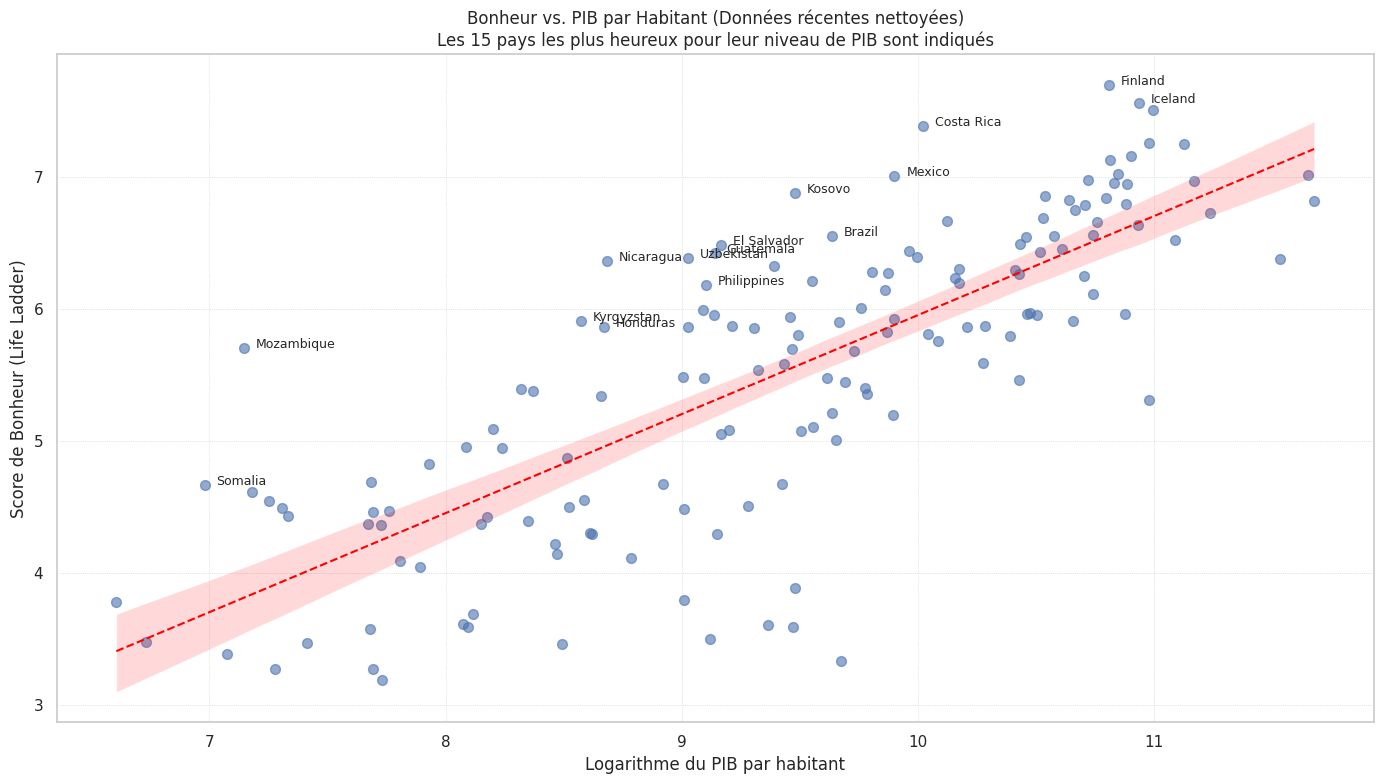

In [10]:
# --- Visualisation Q2 : Scatter Plot avec Outliers ---

# Vérifier si les dataframes nécessaires existent (générés dans la cellule précédente)
q2_data_exists = 'df_q2_analysis_data' in locals() and 'top_overperformers' in locals()

if df_whr_full is not None and q2_data_exists:
    
    plt.figure(figsize=(14, 8))
    
    # Nuage de points + droite de régression en utilisant les données Q2 nettoyées
    ax = sns.regplot(x='Log GDP per capita', y='Life Ladder', data=df_q2_analysis_data,
                     scatter_kws={'alpha': 0.6, 's': 50}, 
                     line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}) 

    # Ajouter les labels pour les N pays surperformants (depuis top_overperformers)
    # Assurez-vous que top_overperformers contient les colonnes x, y, et Country
    for i, country_data in top_overperformers.iterrows():
        plt.text(country_data['Log GDP per capita'] + 0.05, 
                 country_data['Life Ladder'], 
                 country_data['Country'], 
                 fontsize=9)

    plt.title(f'Bonheur vs. PIB par Habitant (Données récentes nettoyées)\nLes {N} pays les plus heureux pour leur niveau de PIB sont indiqués')
    plt.xlabel('Logarithme du PIB par habitant')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()

elif df_whr_full is None:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Visualisation Q2 annulée.")
else:
    print("Les données nécessaires ('df_q2_analysis_data', 'top_overperformers') n'ont pas été créées. Visualisation Q2 annulée.")

**Conclusion (Basée sur le graphique et les résidus Q2)**

Le graphique ci-dessus visualise le score de bonheur (`Life Ladder`) en fonction de la richesse économique (`Log GDP per capita`) pour les données les plus récentes. La ligne rouge pointillée représente la tendance générale : plus un pays est riche, plus son score de bonheur tend à être élevé.

Cependant, de nombreux pays s'écartent de cette tendance. Ceux situés nettement **au-dessus** de la ligne rouge sont les "surperformants" : ils affichent un niveau de bonheur plus élevé que ce que leur PIB seul ne laisserait supposer. Les 15 pays avec le plus grand écart positif sont nommés sur le graphique et listés dans le tableau précédent.

Parmi ces pays qui "surpassent" leur performance économique en termes de bonheur, on note :

* **Une forte présence latino-américaine :** Le **Costa Rica** est très nettement au-dessus de la ligne, suivi par le **Nicaragua**, **El Salvador**, le **Mexique**, le **Guatemala**, le **Honduras** et le **Brésil**.
* **Des cas surprenants à faible revenu :** Le **Mozambique** et la **Somalie** affichent un bonheur remarquablement plus élevé que prédit par leur très faible PIB.
* **Des pays d'Europe et d'Asie Centrale :** Le **Kosovo**, l'**Ouzbékistan** et le **Kirghizstan** se distinguent également. Les **Philippines** sont aussi dans ce groupe.
* **Des pays nordiques déjà riches :** La **Finlande** et l'**Islande**, bien que déjà très riches, parviennent à être *encore plus* heureuses que ce que leur niveau de PIB élevé prédirait.

Ces résultats suggèrent fortement que si la richesse contribue au bonheur, elle n'en est pas le seul déterminant. Des facteurs comme la qualité des liens sociaux, la liberté individuelle, la confiance, la générosité (analysés dans la Question 1) jouent un rôle crucial et permettent à certains pays, notamment en Amérique Latine mais aussi ailleurs, d'atteindre un bien-être subjectif élevé malgré un niveau de richesse parfois modeste ou moyen. Pour les pays déjà riches comme la Finlande ou l'Islande, cela indique une efficacité particulière à convertir la richesse en bien-être subjectif grâce à ces autres facteurs.

# Question 3 : Disparités Régionales du Bonheur

**Objectif :** Examiner comment le score de bonheur (`Life Ladder`) et ses composantes principales (PIB, soutien social, santé, liberté, générosité, corruption) varient en moyenne d'une région géographique à l'autre.

In [11]:
# --- Préparation des Données Régionales ---

if df_whr_full is not None: # Vérifie si le chargement initial (Cellule 3) a réussi
    
    # 1. Charger les données de régions depuis le fichier CPI
    cpi_file_path = 'CSVs/CPI2023_global_results_trends.csv'
    # Si dossier WorldHappinessReport/ : 'WorldHappinessReport/CSVs/CPI2023_global_results_trends.csv'
    try:
        df_regions = pd.read_csv(cpi_file_path, usecols=['Country', 'Region'])
        print(f"Données régionales chargées depuis {cpi_file_path}. {len(df_regions)} pays trouvés.")
        # Nettoyer les noms de région si nécessaire (optionnel)
        # df_regions['Region'] = df_regions['Region'].str.strip() 
    except FileNotFoundError:
        print(f"ERREUR: Le fichier CPI {cpi_file_path} est introuvable.")
        df_regions = None
    except Exception as e:
        print(f"Erreur lors du chargement des régions: {e}")
        df_regions = None

    if df_regions is not None:
        # 2. Sélectionner les données les plus récentes par pays depuis df_whr_full
        df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
        print(f"Données les plus récentes sélectionnées pour {len(df_latest)} pays du WHR.")

        # 3. Fusionner les données récentes du WHR avec les informations de région
        #    ATTENTION: La fusion sur 'Country' peut échouer si les noms ne correspondent pas exactement.
        df_merged_regions = pd.merge(df_latest, df_regions, on='Country', how='left')
        
        # Vérifier combien de pays n'ont pas eu de correspondance de région
        unmatched_countries = df_merged_regions[df_merged_regions['Region'].isnull()]['Country'].nunique()
        if unmatched_countries > 0:
            print(f"Attention: {unmatched_countries} pays n'ont pas pu être associés à une région (vérifiez les noms de pays).")
        
        # Retirer les pays sans région pour l'analyse régionale
        df_regional_data = df_merged_regions.dropna(subset=['Region'])
        print(f"{len(df_regional_data)} observations avec informations régionales disponibles pour l'analyse.")

        # 4. Calculer les scores moyens par région pour les variables clés
        colonnes_analyse_q3 = [
            'Life Ladder', 'Log GDP per capita', 'Social support', 
            'Healthy life expectancy at birth', 'Freedom to make life choices', 
            'Generosity', 'Perceptions of corruption'
        ]
        # Calculer la moyenne pour chaque colonne numérique pertinente, groupée par Région
        # Note: .mean(numeric_only=True) gère automatiquement les colonnes non numériques
        regional_means = df_regional_data.groupby('Region')[colonnes_analyse_q3].mean().reset_index()

        print("\nScores moyens par région :")
        # Afficher le tableau des moyennes régionales
        display(regional_means.round(2)) # Arrondir pour une meilleure lisibilité
        
    else:
        print("Analyse régionale annulée car les données régionales n'ont pas pu être chargées.")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q3 annulée.")

Données régionales chargées depuis CSVs/CPI2023_global_results_trends.csv. 180 pays trouvés.
Données les plus récentes sélectionnées pour 165 pays du WHR.
Attention: 10 pays n'ont pas pu être associés à une région (vérifiez les noms de pays).
155 observations avec informations régionales disponibles pour l'analyse.

Scores moyens par région :


,Region,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,AME,6.16,9.63,0.84,66.00,0.81,-0.02,0.77
1,AP,5.31,9.42,0.76,65.14,0.82,0.13,0.70
2,ECA,5.77,9.59,0.86,66.09,0.83,0.05,0.76
3,MENA,5.36,9.97,0.75,65.28,0.69,0.01,0.75
4,SSA,4.26,8.06,0.65,56.54,0.70,0.03,0.75
5,WE/EU,6.63,10.76,0.90,70.72,0.83,0.02,0.61



Visualisation des scores moyens par région...


/tmp/ipykernel_413135/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_413135/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_413135/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palett

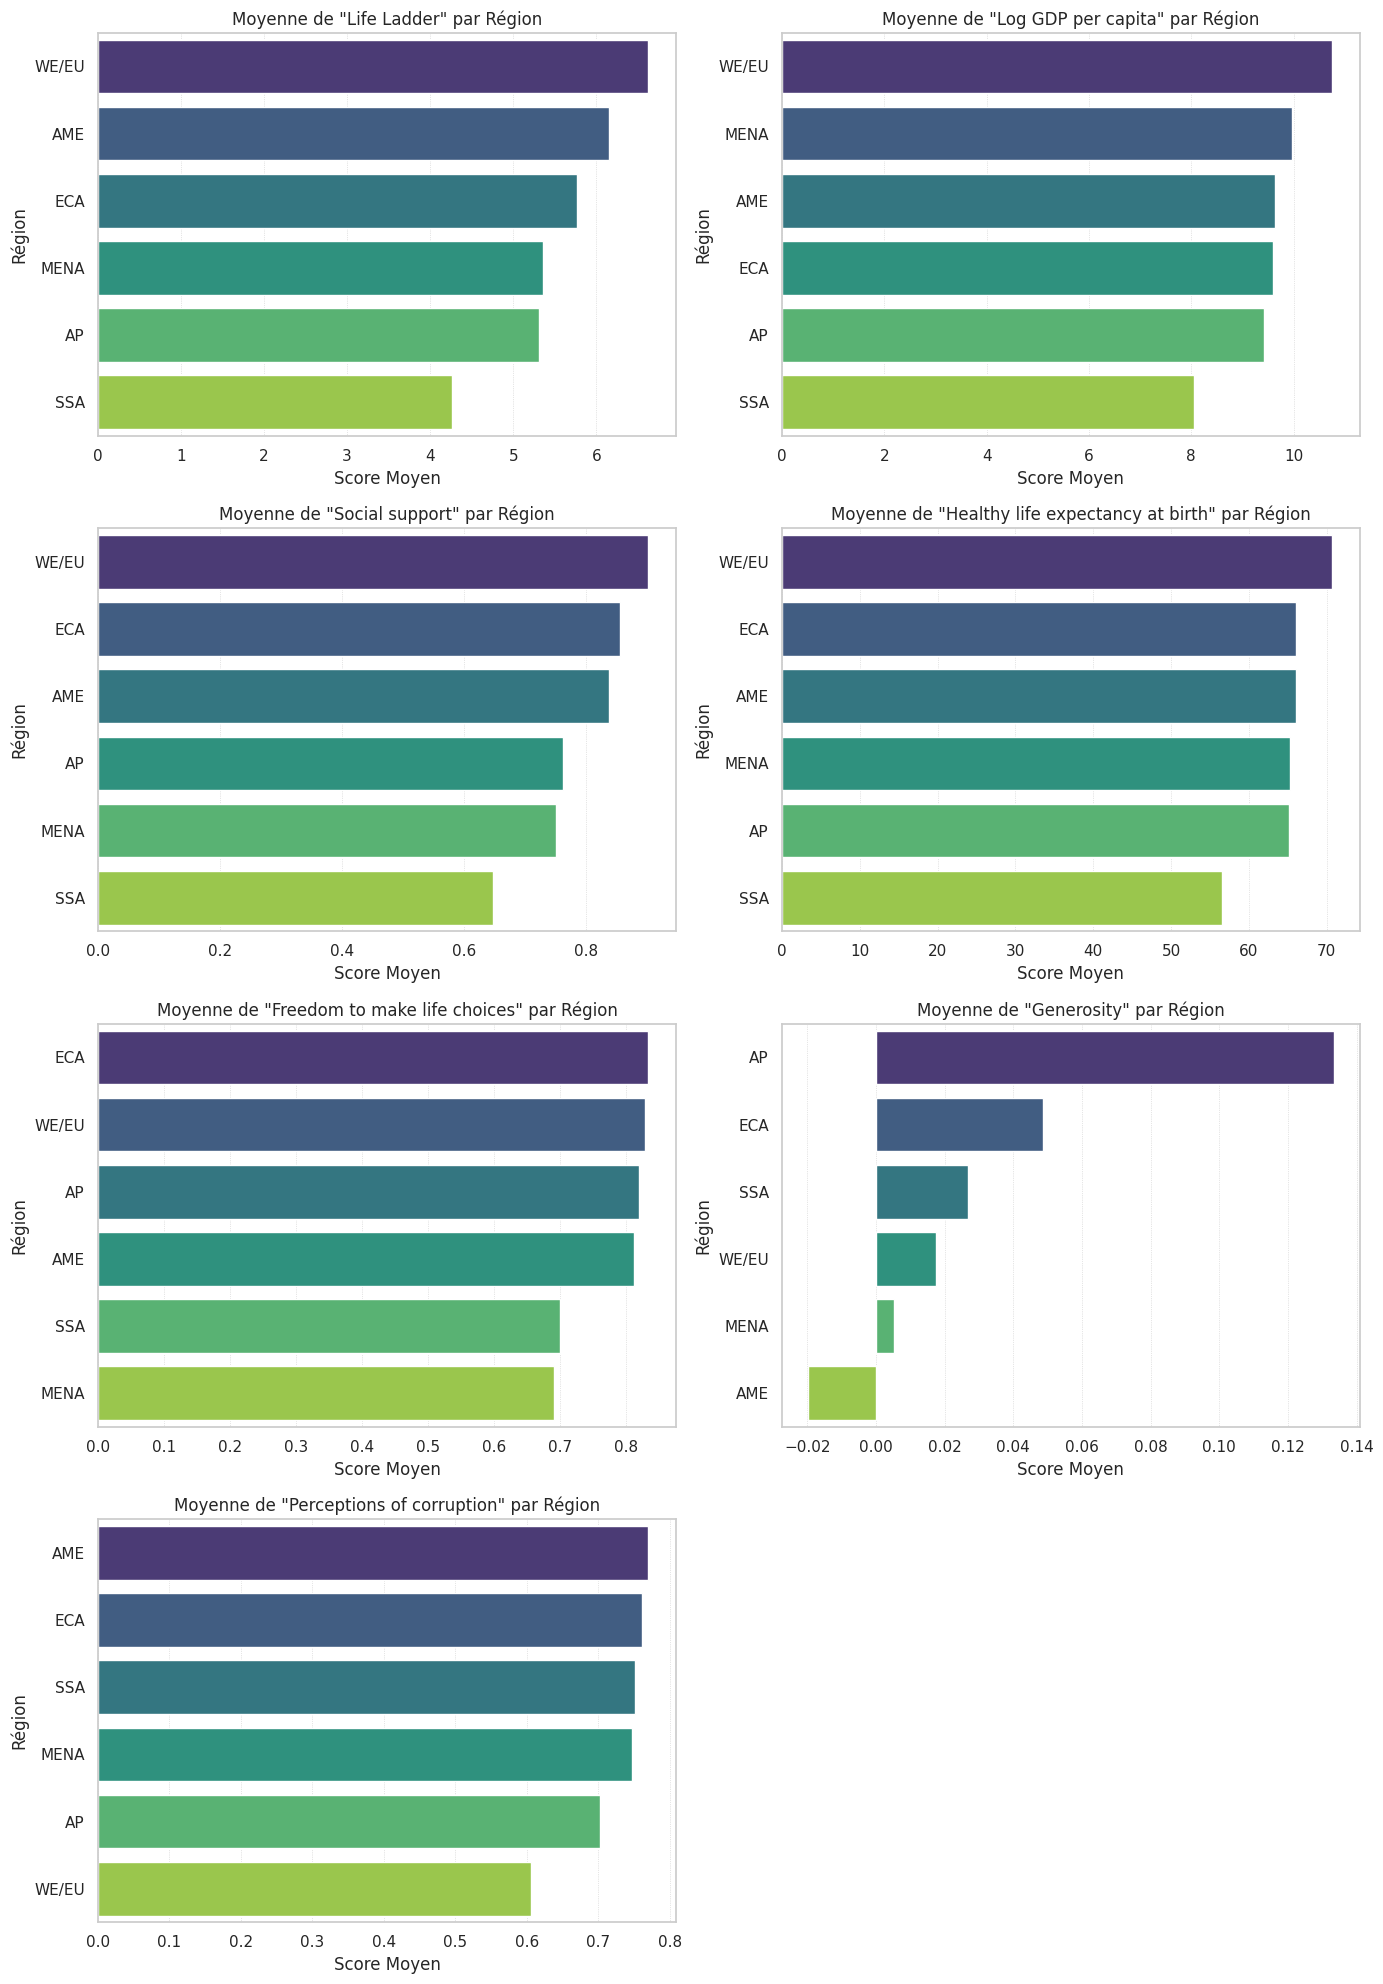

In [12]:
# --- Visualisation des Moyennes Régionales ---

# Vérifier si les données régionales existent
q3_data_exists = 'regional_means' in locals()

if q3_data_exists and not regional_means.empty:
    
    print("\nVisualisation des scores moyens par région...")
    
    # Liste des colonnes à visualiser
    variables_to_plot = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    
    # Nombre de lignes/colonnes pour la grille de graphiques
    n_cols = 2
    n_rows = (len(variables_to_plot) + n_cols - 1) // n_cols

    plt.figure(figsize=(14, n_rows * 5)) # Ajuster la taille globale

    for i, var in enumerate(variables_to_plot):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Trier les régions par la variable actuelle pour une meilleure lisibilité du graphique
        data_sorted = regional_means.sort_values(var, ascending=False)
        
        # Créer le barplot
        sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
        
        plt.title(f'Moyenne de "{var}" par Région')
        plt.xlabel('Score Moyen')
        plt.ylabel('Région') # L'axe Y contient maintenant les noms des régions
        plt.grid(axis='x', linestyle=':', linewidth=0.5)

    plt.tight_layout() # Ajuster l'espacement
    plt.show()

elif not q3_data_exists:
     print("Les données 'regional_means' n'ont pas été créées. Visualisation Q3 annulée.")
else:
     print("Le DataFrame 'regional_means' est vide. Vérifiez les étapes précédentes (chargement, fusion).")

**Conclusion (Basée sur les graphiques des moyennes régionales)**

Les graphiques à barres produits ci-dessus révèlent des disparités régionales nettes concernant le bonheur et ses composantes principales :

1.  **Bonheur (`Life Ladder`) :** La région **WE/EU** (Europe de l'Ouest / UE) affiche le score de bonheur moyen le plus élevé, suivie par **AME** (Amériques). À l'opposé, **SSA** (Afrique Subsaharienne) présente la moyenne la plus faible. Les régions **ECA** (Europe de l'Est / Asie Centrale), **MENA** (Moyen-Orient / Afrique du Nord) et **AP** (Asie-Pacifique) se situent à des niveaux intermédiaires.

2.  **Facteurs Clés :**
    * **Richesse et Santé (`Log GDP per capita`, `Healthy life expectancy`) :** Le classement du bonheur suit globalement celui de la richesse et de l'espérance de vie en bonne santé. **WE/EU** domine largement sur ces deux plans, tandis que **SSA** est nettement en retrait.
    * **Soutien Social (`Social support`) :** **WE/EU** est en tête, mais **ECA** et **AME** montrent aussi des niveaux élevés, indiquant une forte perception de soutien social dans ces régions également. **SSA** a le score le plus bas.
    * **Liberté (`Freedom to make life choices`) :** **WE/EU** rapporte la plus grande liberté de choix en moyenne, suivie de près par **ECA**, **AME**, et **AP**. Les régions **SSA** et surtout **MENA** affichent les scores moyens les plus faibles sur ce critère.
    * **Générosité (`Generosity`) :** Le classement est différent ici. **AP** semble être la région la plus généreuse en moyenne, suivie par **ECA** et **SSA**. Les régions **WE/EU**, **MENA** et **AME** montrent des niveaux moyens plus bas, voire légèrement négatifs pour ces dernières.
    * **Corruption (`Perceptions of corruption`) :** **WE/EU** se distingue par la perception de corruption la plus faible (score le plus bas). À l'inverse, **AME** et **ECA** affichent les perceptions de corruption les plus élevées en moyenne (scores les plus hauts). **AP** se situe remarquablement bien (deuxième score le plus bas après WE/EU).

**Synthèse :** Les différences de bonheur moyen entre les régions s'expliquent en grande partie par les écarts de richesse, de santé, de soutien social et de liberté. La région WE/EU excelle sur la plupart de ces indicateurs ainsi que sur la faible corruption perçue. Les Amériques (AME) affichent un bonheur élevé malgré une perception de corruption très forte, suggérant que d'autres facteurs (bon soutien social, liberté, etc.) compensent. L'Asie-Pacifique (AP) se distingue par une forte générosité et une faible perception de corruption relative à son niveau de bonheur/richesse. L'Afrique Subsaharienne (SSA) est confrontée aux défis les plus importants sur la plupart des indicateurs, à l'exception notable d'une générosité moyenne relativement élevée. Ces profils régionaux variés soulignent l'interaction complexe des différents facteurs dans la détermination du bien-être subjectif à travers le monde.